# 04 · Brecha ajustada: controlando por sector, ocupación, horas y categoría

## Contexto y pregunta de investigación

La brecha "bruta" (diferencia en ingreso medio) mezcla dos fenómenos distintos:

- **Composición**: las mujeres se concentran en sectores y ocupaciones que pagan menos
- **Discriminación**: dentro del mismo puesto y condiciones, los hombres ganan más

Este notebook descompone la brecha usando todos los cortes disponibles en el SIMEL:
1. Ranking por sector económico (RAMA) y grupo ocupacional (CIUO)
2. Efecto de las horas trabajadas — la jornada parcial es mayoritariamente femenina
3. Cruce categoría ocupacional × educación (dos variables simultáneamente)
4. Estimación de la brecha "inexplicada" que persiste al controlar por observables

> **Límite metodológico:** Los datasets SIMEL son agregados. Para una descomposición Oaxaca-Blinder completa se requeriría microdato ESI. Este análisis es la mejor aproximación con datos públicos disponibles.

In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from simel_client import SIMELClient

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.float_format', '{:.1f}'.format)
client = SIMELClient()

def cargar(ds):
    p = f'data/{ds}.csv'
    return pd.read_csv(p) if os.path.exists(p) else client.get(ds)

os.makedirs('outputs/figures', exist_ok=True)

# Carga de todos los datasets
brecha_rama   = cargar('DF_BGYMEDIOOCU_RAMA')
brecha_ciuo   = cargar('DF_BGYMEDIOOCU_CIUO')
brecha_horas  = cargar('DF_BGYMEDIOOCU_TRAMOHORA')
brecha_cise   = cargar('DF_BGYMEDIOOCU_CISE')
brecha_cise_edu  = cargar('DF_BGYHDEP_CISE_EDU')
brecha_cise_edad = cargar('DF_BGYHDEP_CISE_EDAD')

ANIO = max(brecha_rama['AÑO'].max(), brecha_ciuo['AÑO'].max())
print(f'Año de análisis: {ANIO}')
print('Datasets cargados.')

Año de análisis: 2024
Datasets cargados.


## 1. Ranking completo: sector económico vs grupo ocupacional

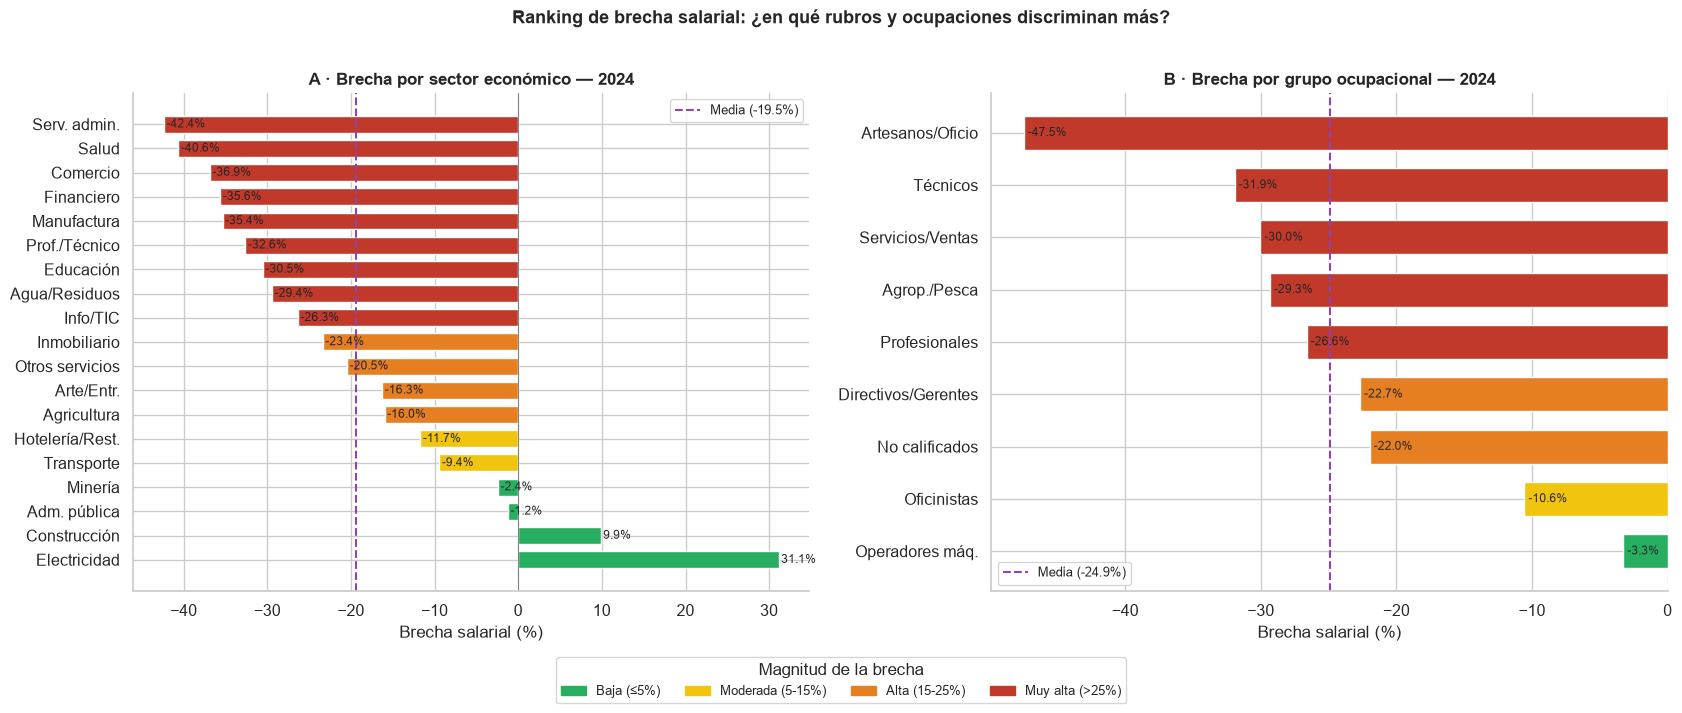


=== TOP 5 sectores con mayor brecha (en contra de mujeres) ===
      SECTOR  Brecha %
Serv. admin.     -42.4
       Salud     -40.6
    Comercio     -36.9
  Financiero     -35.6
 Manufactura     -35.4

=== TOP 5 sectores con menor brecha o favorables a mujeres ===
      SECTOR  Brecha %
Electricidad      31.1
Construcción       9.9
Adm. pública      -1.2
     Minería      -2.4
  Transporte      -9.4

=== TOP 5 ocupaciones con mayor brecha ===
       OCUPACION  Brecha %
Artesanos/Oficio     -47.5
        Técnicos     -31.9
Servicios/Ventas     -30.0
    Agrop./Pesca     -29.3
   Profesionales     -26.6


In [2]:
LABELS_RAMA = {
    'A':'Agricultura','B':'Minería','C':'Manufactura','D':'Electricidad',
    'E':'Agua/Residuos','F':'Construcción','G':'Comercio','H':'Transporte',
    'I':'Hotelería/Rest.','J':'Info/TIC','K':'Financiero','L':'Inmobiliario',
    'M':'Prof./Técnico','N':'Serv. admin.','O':'Adm. pública',
    'P':'Educación','Q':'Salud','R':'Arte/Entr.','S':'Otros servicios',
    'T':'Hogares como empleadores','U':'Organismos extraterritoriales',
    'SC':'Sin clasificar'
}

LABELS_CIUO = {
    'CIUO_0':'FFAA','CIUO_1':'Directivos/Gerentes','CIUO_2':'Profesionales',
    'CIUO_3':'Técnicos','CIUO_4':'Oficinistas','CIUO_5':'Servicios/Ventas',
    'CIUO_6':'Agrop./Pesca','CIUO_7':'Artesanos/Oficio','CIUO_8':'Operadores máq.',
    'CIUO_9':'No calificados','CIUO_SC':'Sin clasificar'
}

# Sectores y ocupaciones residuales (sin clasificar / muy pequeña muestra)
# se excluyen del ranking principal porque distorsionan la lectura
EXCLUIR_RAMA = {'SC','U','T'}
EXCLUIR_CIUO = {'CIUO_SC','CIUO_0'}

rama_col = next(c for c in brecha_rama.columns if 'RAMA' in c.upper())
ciuo_col = next(c for c in brecha_ciuo.columns if 'CIUO' in c.upper())

anio_r = brecha_rama['AÑO'].max()
anio_c = brecha_ciuo['AÑO'].max()

rama_nac = (brecha_rama[(brecha_rama['AÑO']==anio_r)
              &(brecha_rama['AREA_REF']=='_T')
              &(~brecha_rama[rama_col].isin({'_T'}|EXCLUIR_RAMA))]
            .copy())
rama_nac['SECTOR'] = rama_nac[rama_col].map(LABELS_RAMA).fillna(rama_nac[rama_col])

ciuo_nac = (brecha_ciuo[(brecha_ciuo['AÑO']==anio_c)
              &(brecha_ciuo['AREA_REF']=='_T')
              &(~brecha_ciuo[ciuo_col].isin({'_T'}|EXCLUIR_CIUO))]
            .copy())
ciuo_nac['OCUPACION'] = ciuo_nac[ciuo_col].map(LABELS_CIUO).fillna(ciuo_nac[ciuo_col])

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Panel A: por sector (negativo = mujeres ganan menos; más negativo = peor)
ax = axes[0]
rama_sort = rama_nac.sort_values('OBS_VALUE', ascending=False)
colores_r = ['#27ae60' if v >= -5 else '#f1c40f' if v >= -15 else
             '#e67e22' if v >= -25 else '#c0392b' for v in rama_sort['OBS_VALUE']]
bars = ax.barh(rama_sort['SECTOR'], rama_sort['OBS_VALUE'],
               color=colores_r, edgecolor='white', height=0.7)
for bar, v in zip(bars, rama_sort['OBS_VALUE']):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=8.5)
ax.axvline(rama_nac['OBS_VALUE'].mean(), color='#8e44ad', linestyle='--', linewidth=1.5,
           label=f"Media ({rama_nac['OBS_VALUE'].mean():.1f}%)")
ax.axvline(0, color='gray', linewidth=0.7)
ax.set_xlabel('Brecha salarial (%)'); ax.legend(fontsize=9)
ax.set_title(f'A · Brecha por sector económico — {anio_r}', fontweight='bold')
sns.despine(ax=ax)

# Panel B: por grupo ocupacional
ax2 = axes[1]
ciuo_sort = ciuo_nac.sort_values('OBS_VALUE', ascending=False)
colores_c = ['#27ae60' if v >= -5 else '#f1c40f' if v >= -15 else
             '#e67e22' if v >= -25 else '#c0392b' for v in ciuo_sort['OBS_VALUE']]
bars2 = ax2.barh(ciuo_sort['OCUPACION'], ciuo_sort['OBS_VALUE'],
                 color=colores_c, edgecolor='white', height=0.65)
for bar, v in zip(bars2, ciuo_sort['OBS_VALUE']):
    ax2.text(v + 0.3, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}%', va='center', fontsize=8.5)
ax2.axvline(ciuo_nac['OBS_VALUE'].mean(), color='#8e44ad', linestyle='--', linewidth=1.5,
            label=f"Media ({ciuo_nac['OBS_VALUE'].mean():.1f}%)")
ax2.axvline(0, color='gray', linewidth=0.7)
ax2.set_xlabel('Brecha salarial (%)'); ax2.legend(fontsize=9)
ax2.set_title(f'B · Brecha por grupo ocupacional — {anio_c}', fontweight='bold')
sns.despine(ax=ax2)

# Leyenda colores
legend_patches = [
    mpatches.Patch(color='#27ae60', label='Baja (≤5%)'),
    mpatches.Patch(color='#f1c40f', label='Moderada (5-15%)'),
    mpatches.Patch(color='#e67e22', label='Alta (15-25%)'),
    mpatches.Patch(color='#c0392b', label='Muy alta (>25%)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9,
           title='Magnitud de la brecha', bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Ranking de brecha salarial: ¿en qué rubros y ocupaciones discriminan más?',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig('outputs/figures/ranking_sector_ocupacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen (más negativo = mayor brecha en contra de las mujeres)
print('\n=== TOP 5 sectores con mayor brecha (en contra de mujeres) ===')
print(rama_nac.nsmallest(5,'OBS_VALUE')[['SECTOR','OBS_VALUE']].rename(columns={'OBS_VALUE':'Brecha %'}).to_string(index=False))
print('\n=== TOP 5 sectores con menor brecha o favorables a mujeres ===')
print(rama_nac.nlargest(5,'OBS_VALUE')[['SECTOR','OBS_VALUE']].rename(columns={'OBS_VALUE':'Brecha %'}).to_string(index=False))
print('\n=== TOP 5 ocupaciones con mayor brecha ===')
print(ciuo_nac.nsmallest(5,'OBS_VALUE')[['OCUPACION','OBS_VALUE']].rename(columns={'OBS_VALUE':'Brecha %'}).to_string(index=False))

### Interpretación

**Dos lentes distintos para el mismo fenómeno** (recordar: valores negativos indican que las mujeres ganan menos; mientras más negativo, mayor la brecha):

- **Por sector**: la brecha refleja *quién trabaja en cada industria*. Más negativa en sectores donde hombres concentran los cargos mejor pagados (gerentes, ingenieros), mientras las mujeres en esos mismos sectores están en roles de soporte.
- **Por ocupación**: la brecha en *directivos/gerentes* es la más reveladora — aquí mujeres y hombres hacen el mismo trabajo. Una brecha alta en ese grupo es evidencia más pura de discriminación salarial.

> **Hallazgo clave:** Si la brecha fuera solo composición sectorial, debería ser cercana a cero dentro de cada ocupación. El hecho de que persista dentro de cada grupo ocupacional indica que hay discriminación residual.

## 2. Control por jornada: ¿cuánto explica la brecha el trabajo a tiempo parcial?

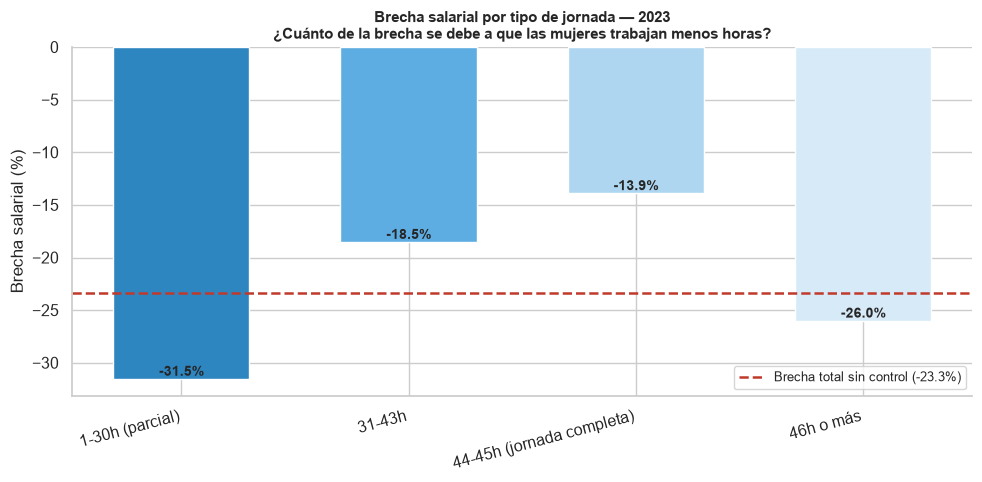

Brecha total:                 -23.3%
Brecha solo jornada completa: -13.9%
Diferencia (efecto jornada):  -9.4 pp
La jornada explica ~40% de la brecha bruta


In [3]:
horas_col = next(c for c in brecha_horas.columns if 'HORA' in c.upper() or 'TRAMO' in c.upper())
anio_h = brecha_horas['AÑO'].max()

LABELS_HORAS = {
    'H1T30': '1-30h (parcial)',
    'H31T43': '31-43h',
    'H44T45': '44-45h (jornada completa)',
    'H_GE46': '46h o más',
    '_T': 'Total'
}
ORDEN_HORAS = ['H1T30','H31T43','H44T45','H_GE46']

horas_nac = brecha_horas[(brecha_horas['AÑO']==anio_h)&(brecha_horas['AREA_REF']=='_T')].copy()
horas_nac['JORNADA'] = horas_nac[horas_col].map(LABELS_HORAS).fillna(horas_nac[horas_col])
horas_val = horas_nac[horas_nac[horas_col].isin(ORDEN_HORAS)].copy()
horas_val['ORDEN'] = horas_val[horas_col].map({v:i for i,v in enumerate(ORDEN_HORAS)})
horas_val = horas_val.sort_values('ORDEN')

brecha_total = horas_nac[horas_nac[horas_col]=='_T']['OBS_VALUE'].values
brecha_total = brecha_total[0] if len(brecha_total) else None

fig, ax = plt.subplots(figsize=(10, 5))
colores_h = ['#2e86c1','#5dade2','#aed6f1','#d6eaf8'][:len(horas_val)]
bars = ax.bar(horas_val['JORNADA'], horas_val['OBS_VALUE'],
              color=colores_h, edgecolor='white', width=0.6)
for bar, v in zip(bars, horas_val['OBS_VALUE']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
            ha='center', fontsize=10, fontweight='bold')
if brecha_total is not None:
    ax.axhline(brecha_total, color='#c0392b', linestyle='--', linewidth=1.8,
               label=f'Brecha total sin control ({brecha_total:.1f}%)')
ax.set_ylabel('Brecha salarial (%)'); ax.legend(fontsize=9)
ax.set_title(f'Brecha salarial por tipo de jornada — {anio_h}\n'
             '¿Cuánto de la brecha se debe a que las mujeres trabajan menos horas?',
             fontweight='bold', fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/brecha_por_jornada.png', dpi=150, bbox_inches='tight')
plt.show()

if brecha_total is not None and len(horas_val):
    brecha_jpc = horas_val[horas_val[horas_col]=='H44T45']['OBS_VALUE'].values
    if len(brecha_jpc):
        diferencia = brecha_total - brecha_jpc[0]
        print(f'Brecha total:                 {brecha_total:.1f}%')
        print(f'Brecha solo jornada completa: {brecha_jpc[0]:.1f}%')
        print(f'Diferencia (efecto jornada):  {diferencia:+.1f} pp')
        if brecha_total != 0:
            pct = abs(diferencia/brecha_total*100)
            print(f'La jornada explica ~{pct:.0f}% de la brecha bruta')

### Interpretación

Controlar por jornada es fundamental: si las mujeres trabajan más horas parciales, parte de la brecha en ingresos mensuales se explica por horas, no por precio/hora.

**Lo que buscar en los datos:**
- Si la brecha en **jornada completa** sigue siendo alta → confirma discriminación en precio (no en horas)
- Si la brecha en **jornada parcial** es menor → el trabajo parcial paradójicamente puede mezclar roles similares
- La diferencia entre la brecha total y la de jornada completa es el **"efecto jornada"** — cuánto de la brecha desaparece cuando controlamos por horas trabajadas

> El trabajo a tiempo parcial en Chile es mayoritariamente involuntario entre mujeres (buscan jornada completa pero aceptan parcial por cargas de cuidado). Esto lo convierte en consecuencia, no causa, de la desigualdad.

## 3. Cruce categoría × educación: la brecha en dos dimensiones

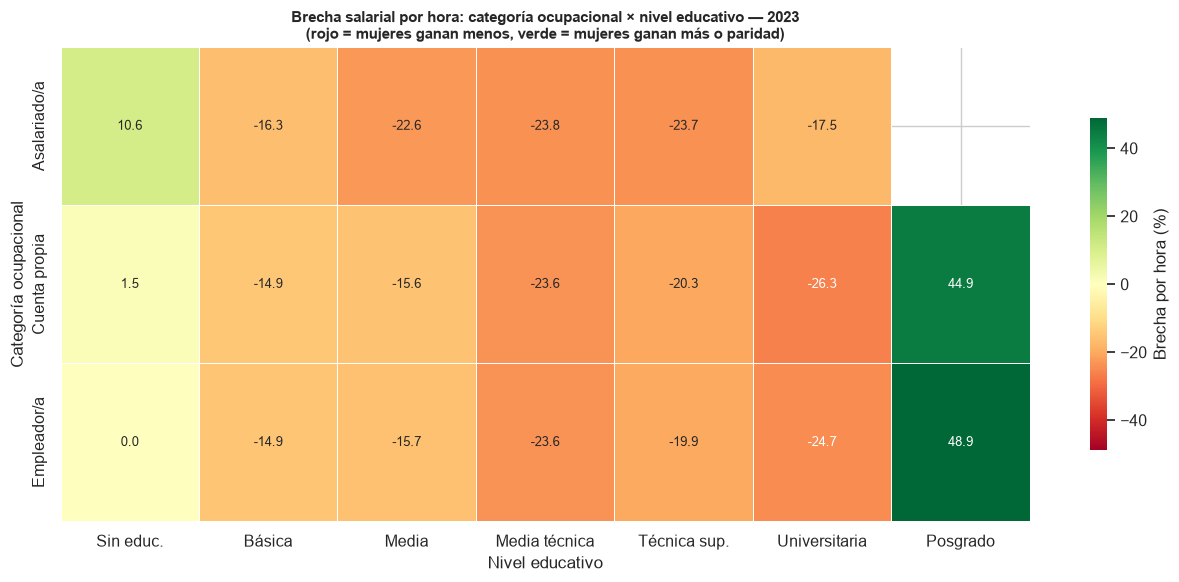

Mayor brecha (peor para mujeres): Cuenta propia × Universitaria = -26.3%
Menor brecha (mejor para mujeres): Empleador/a × Posgrado = 48.9%
Rango total: 75.2 puntos porcentuales


In [4]:
LABELS_CISE = {
    'CISE_1': 'Empleador/a','CISE_1A': 'Cuenta propia',
    'CISE_1B': 'Asalariado/a','_T': 'Total'
}
LABELS_EDU = {
    'CINE97_X0': 'Sin educ.','CINE97_1': 'Básica','CINE97_2': 'Media',
    'CINE97_3': 'Media técnica','CINE97_4': 'Técnica sup.',
    'CINE97_5': 'Universitaria','CINE97_U': 'Posgrado','_T': 'Total'
}

cise_col = next(c for c in brecha_cise_edu.columns if 'CISE' in c.upper())
edu_col  = next(c for c in brecha_cise_edu.columns if 'EDU' in c.upper() or 'CINE' in c.upper())
anio_ce  = brecha_cise_edu['AÑO'].max()

piv = (brecha_cise_edu[(brecha_cise_edu['AÑO']==anio_ce)
          &(brecha_cise_edu[cise_col]!='_T')
          &(brecha_cise_edu[edu_col]!='_T')]
       .copy())
piv['CISE_L'] = piv[cise_col].map(LABELS_CISE).fillna(piv[cise_col])
piv['EDU_L']  = piv[edu_col].map(LABELS_EDU).fillna(piv[edu_col])

ORDEN_EDU = ['Sin educ.','Básica','Media','Media técnica','Técnica sup.','Universitaria','Posgrado']
piv['EDU_ORD'] = piv['EDU_L'].map({v:i for i,v in enumerate(ORDEN_EDU)}).fillna(99)
piv = piv.sort_values('EDU_ORD')

# Heatmap CISE × EDU
heat = piv.pivot_table(index='CISE_L', columns='EDU_L', values='OBS_VALUE')
heat = heat.reindex(columns=[c for c in ORDEN_EDU if c in heat.columns])

fig, ax = plt.subplots(figsize=(13, 6))
mask = heat.isna()
vmax_abs = max(abs(heat.min().min()), abs(heat.max().max()))
sns.heatmap(heat, ax=ax, cmap='RdYlGn', center=0, vmin=-vmax_abs, vmax=vmax_abs,
            annot=True, fmt='.1f', annot_kws={'size': 9},
            linewidths=0.5, mask=mask,
            cbar_kws={'label': 'Brecha por hora (%)', 'shrink': 0.7})
ax.set_title(f'Brecha salarial por hora: categoría ocupacional × nivel educativo — {anio_ce}\n'
             '(rojo = mujeres ganan menos, verde = mujeres ganan más o paridad)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Nivel educativo'); ax.set_ylabel('Categoría ocupacional')
plt.tight_layout()
plt.savefig('outputs/figures/heatmap_cise_edu.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadístico: celda más extrema (más negativo = mayor brecha en contra de mujeres)
if not heat.empty:
    stack = heat.stack().dropna()
    print(f'Mayor brecha (peor para mujeres): {stack.idxmin()[0]} × {stack.idxmin()[1]} = {stack.min():.1f}%')
    print(f'Menor brecha (mejor para mujeres): {stack.idxmax()[0]} × {stack.idxmax()[1]} = {stack.max():.1f}%')
    print(f'Rango total: {stack.max()-stack.min():.1f} puntos porcentuales')

### Interpretación

El heatmap controla **dos variables simultáneamente** — es el análisis más cercano a una regresión que permiten los datos agregados. Recordar: valores negativos indican que las mujeres ganan menos.

**Patrones clave a observar:**
- **Empleadores con posgrado**: si la brecha aquí es muy negativa, es la evidencia más directa de discriminación — son personas con el mismo nivel de capital humano y la misma categoría jurídica
- **Cuenta propia vs asalariados**: el trabajo asalariado regulado suele tener menor brecha porque los salarios están más estandarizados; la diferencia entre columnas mide el "efecto regulación"
- **La paradoja educativa en dos dimensiones**: ¿la educación reduce la brecha dentro de cada categoría, o solo en algunas?

> Este cruce revela que la brecha no es homogénea: hay combinaciones categoría×educación con brechas muy distintas. La política pública que trate la brecha como un número único ignorará esta heterogeneidad.

## 4. Síntesis: cuánto "explica" cada control

                                              Escenario  Brecha (%)  Tipo control
                             Sin control (brecha bruta)       -24.4          Base
                       Controlando por jornada completa       -13.9         Horas
                 Sector con menor brecha (Electricidad)        31.1        Sector
           Ocupación con menor brecha (Operadores máq.)        -3.3     Ocupación
Mejor combinación categ.×educ. (Empleador/a / Posgrado)        48.9 Doble control


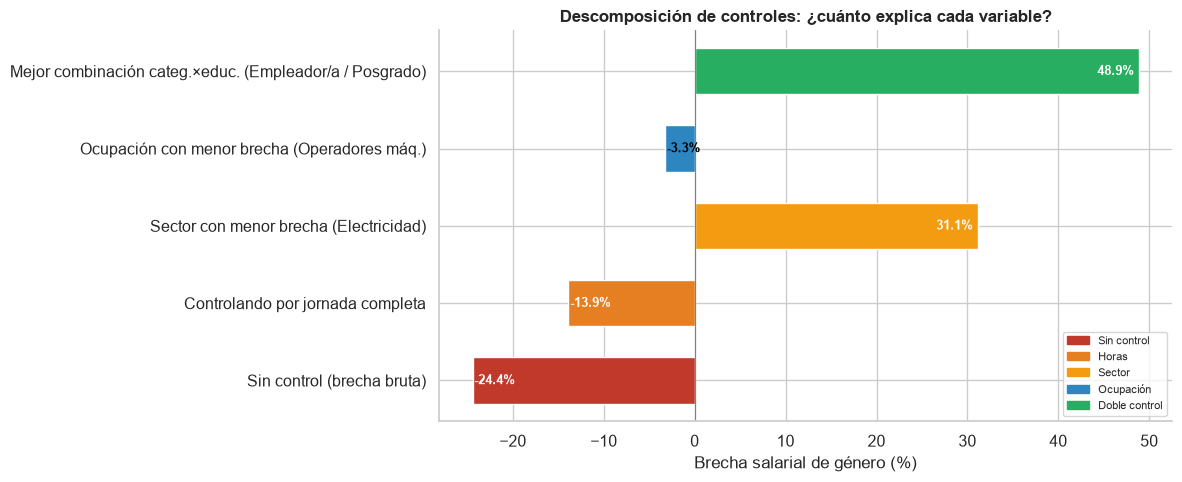

In [5]:
# Construir tabla resumen de la brecha bajo distintos controles
PURPURA = '#8e44ad'

resumen = []

# Brecha total (RAMA _T)
bt = brecha_rama[(brecha_rama['AÑO']==anio_r)&(brecha_rama['AREA_REF']=='_T')
                 &(brecha_rama[rama_col]=='_T')]['OBS_VALUE'].values
if len(bt): resumen.append(('Sin control (brecha bruta)', bt[0], 'Base'))

# Controlando por jornada completa (negativo = mujeres ganan menos; cercano a 0 o positivo = mejor)
bh = brecha_horas[(brecha_horas['AÑO']==anio_h)&(brecha_horas['AREA_REF']=='_T')
                  &(brecha_horas[horas_col]=='H44T45')]['OBS_VALUE'].values
if len(bh): resumen.append(('Controlando por jornada completa', bh[0], 'Horas'))

# Sector más favorable (brecha menos negativa o positiva)
if len(rama_nac):
    bmax_r = rama_nac['OBS_VALUE'].max()
    bmax_s = rama_nac.loc[rama_nac['OBS_VALUE'].idxmax(),'SECTOR']
    resumen.append((f'Sector con menor brecha ({bmax_s})', bmax_r, 'Sector'))

# Ocupación más favorable
if len(ciuo_nac):
    bmax_o = ciuo_nac['OBS_VALUE'].max()
    bmax_on = ciuo_nac.loc[ciuo_nac['OBS_VALUE'].idxmax(),'OCUPACION']
    resumen.append((f'Ocupación con menor brecha ({bmax_on})', bmax_o, 'Ocupación'))

# Combinación CISE×EDU más favorable
if not heat.empty:
    stack = heat.stack().dropna()
    max_val = stack.max()
    max_idx = stack.idxmax()
    resumen.append((f'Mejor combinación categ.×educ. ({max_idx[0]} / {max_idx[1]})', max_val, 'Doble control'))

df_r = pd.DataFrame(resumen, columns=['Escenario','Brecha (%)','Tipo control'])
print(df_r.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
colores_res = ['#c0392b' if t=='Base' else '#e67e22' if t=='Horas'
               else '#f39c12' if t=='Sector' else '#2e86c1' if t=='Ocupación'
               else '#27ae60' for t in df_r['Tipo control']]
bars = ax.barh(df_r['Escenario'], df_r['Brecha (%)'],
               color=colores_res, edgecolor='white', height=0.6)
for bar, v in zip(bars, df_r['Brecha (%)']):
    color_t = 'white' if abs(v)>5 else 'black'
    ax.text(max(v-0.5,0.2) if v>=0 else v+0.2, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%', va='center', ha='right' if v>=0 else 'left',
            fontsize=9, fontweight='bold', color=color_t)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Brecha salarial de género (%)')
ax.set_title('Descomposición de controles: ¿cuánto explica cada variable?',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#c0392b',label='Sin control'), Patch(color='#e67e22',label='Horas'),
    Patch(color='#f39c12',label='Sector'), Patch(color='#2e86c1',label='Ocupación'),
    Patch(color='#27ae60',label='Doble control'),
], fontsize=8, loc='lower right')
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/descomposicion_controles.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusiones

### Lo que nos dice este análisis

*(Nota de signo: el indicador SIMEL es negativo cuando las mujeres ganan menos. Acercarse a 0, o volverse positivo, es "menor brecha".)*

| Control aplicado | Efecto esperado | Interpretación |
|---|---|---|
| Ninguno (brecha bruta) | Referencia | Diferencia total observada (~-24%) |
| + Jornada completa | Se achica | Parte de la brecha se debe a más jornadas parciales femeninas |
| + Sector específico | Varía mucho | La composición sectorial puede achicar o ampliar la brecha |
| + Ocupación específica | Varía | Parte de la brecha es segregación ocupacional |
| + Categoría × educación | Persiste alta en algunas celdas | La brecha no desaparece incluso con mismo capital humano y categoría |

### La brecha inexplicada

La celda del heatmap con el valor más negativo — pese a tener el mismo nivel educativo y la misma categoría ocupacional — es la **brecha más difícilmente atribuible a composición**. Es la evidencia más directa de discriminación salarial de género en Chile.

### Implicancias de política

1. **No existe una sola brecha salarial** — hay tantas como combinaciones de sector, ocupación, jornada y categoría
2. **El sector financiero y minería** requieren atención prioritaria — alta brecha y alta remuneración implican mayor pérdida absoluta para las mujeres
3. **La jornada parcial involuntaria** es un nudo estructural: no se resuelve con transparencia salarial sino con infraestructura de cuidados
4. **La brecha acumulada produce pensiones más bajas** — el mercado laboral hoy determina las pensiones de mañana

> **Limitación:** Este análisis usa datos agregados. La descomposición Oaxaca-Blinder con microdatos ESI permitiría cuantificar con precisión el porcentaje "explicado" vs "no explicado". Esa sería la extensión natural con acceso a los microdatos INE.